In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("bank_kredit_simulyasiyasi.csv")

In [3]:
df.head(10)

,MüştəriID,AdSoyad,DoğumTarixi,Cins,TəhsilSəviyyəsi,MəşğulluqStatusu,AylıqGəlir,KreditNövü,KreditMəbləği,KreditMəqsədi,FaizDərəcəsi,KreditSkoru,DigərKreditlərinSayı,KeçmişdəGecikmə,QaraSiyahida,MüraciətStatusu,YoxlayıcınınQeydləri
0,83085499,Aydan Qasımova,07-13-04,Qadın,Magistr,Tələbə,288,Təhsil krediti,1333,dövriyyə vəsaitlərinin artırılması - Biznes kr...,21.15,692.0,1,Xeyr,Xeyr,Təsdiqlənib,Müştərinin gəliri və krediti təsdiqləndi
1,26747165,Tural Rzayev,24/12/1973,K,Bakalavr tehsili,İşləyən,3680,Nağd istehlak krediti,11291,şəxsi istehlak məqsədi,22.32,1525.0,4,Bəli,Xeyr,Təsdiqlənib,Müştərinin gəliri və krediti təsdiqləndi
2,64397716,Aydan Əhmədova,1979-08-04,NaN,Orta məktəb,İşsiz,295,Nağd istehlak krediti,444,məişət avadanlığı alışı,16.92,419.0,0,NaN,Xeyr,Rədd edilib,Aşağı kredit reytinqi
3,47555276,Ayan Hüseynova,1980-05-24,qadin,Bakalavr,İşləyən,3512,Avtomobil krediti,33256,tibbi xərclər,19.91,1082.0,2,Xeyr,Bəli,Rədd edilib,'Qara siyahı'da olmaq
4,18690085,Emin Rüstəmov,1983-02-21,kişi,Bakalavr tehsili,Sahibkar,4593,Mikro kredit,35554,əsas vəsaitlərin alınması - Biznes krediti,11.89,1247.0,2,Bəli,Xeyr,Təsdiqlənib,Bütün sənədlər qaydasındadır | Yoxlayıcı_ID: 613
5,58596955,Məryəm Səfərova,03-23-97,Qadın,Orta məktəb,İşsiz,81,Nağd istehlak krediti,840 AZN,məişət avadanlığı alışı,17.13,440.0,1,Xeyr,Xeyr,Rədd edilib,Aşağı kredit reytinqi
6,67362073,Cavid Məmmədov,1983-05-26,K,Magistr,İşləyən,888 manat,Nağd istehlak krediti,9865,toy xərcləri,13.17,1287.0,0,NaN,Xeyr,Təsdiqlənib,Müştərinin gəliri və krediti təsdiqləndi
7,76328629,Aylin Əliyeva,2001-10-17,qadin,Bakalavr,İşləyən,3682,Nağd istehlak krediti,6620,şəxsi istehlak məqsədi,11.92,841.0,3,Xeyr,Xeyr,Təsdiqlənib,Zaminlik məsələləri
8,27470674,Fatimə Hüseynova,14/06/2005,qadin,Magistr,Tələbə,168,Təhsil krediti,2285 manat,Biznes krediti,22.98,744.0,1,Xeyr,Xeyr,Təsdiqlənib,Müştərinin gəliri və krediti təsdiqləndi
9,35733064,Babayev Əli,1992-04-20,K,Magistr,Sahibkar,7458,Mikro kredit,96059,əsas vəsaitlərin alınması - Biznes krediti,16.82,1501.0,2,Bəli,Xeyr,Təsdiqlənib,Müştərinin gəliri və krediti təsdiqləndi


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MüştəriID             5150 non-null   int64  
 1   AdSoyad               5150 non-null   object 
 2   DoğumTarixi           5150 non-null   object 
 3   Cins                  3823 non-null   object 
 4   TəhsilSəviyyəsi       5150 non-null   object 
 5   MəşğulluqStatusu      5150 non-null   object 
 6   AylıqGəlir            5008 non-null   object 
 7   KreditNövü            5150 non-null   object 
 8   KreditMəbləği         5150 non-null   object 
 9   KreditMəqsədi         5150 non-null   object 
 10  FaizDərəcəsi          5150 non-null   float64
 11  KreditSkoru           4929 non-null   float64
 12  DigərKreditlərinSayı  5150 non-null   int64  
 13  KeçmişdəGecikmə       3703 non-null   object 
 14  QaraSiyahida          5150 non-null   object 
 15  MüraciətStatusu      

In [5]:
df.isnull().sum()

,0
MüştəriID,0
AdSoyad,0
DoğumTarixi,0
Cins,1327
TəhsilSəviyyəsi,0
MəşğulluqStatusu,0
AylıqGəlir,142
KreditNövü,0
KreditMəbləği,0
KreditMəqsədi,0


In [6]:
df['AdSoyad'].value_counts()

,count
AdSoyad,
Anar Əhmədov,17
Nigar Tağıyeva,16
Nigar İsmayılova,15
Zülfiyyə Cavadova,14
Yusif Nəsirov,13
...,...
hüseyn tağıyev,1
orxan rəhimov,1
aylin əhmədova,1


In [7]:
import re

df['AdSoyad'] = df['AdSoyad'].astype(str).str.strip()
df['AdSoyad'] = df['AdSoyad'].apply(lambda x: re.sub(r'[^A-Za-zƏÖÜĞÇŞİəöüğçşı\s]', '', x))
df['AdSoyad'] = df['AdSoyad'].str.lower().str.title()
df['AdSoyad'] = df['AdSoyad'].apply(lambda x: ' '.join(x.split()))

name_parts = df['AdSoyad'].str.split(' ', n=1, expand=True)
first_words = name_parts[0].value_counts()
second_words = name_parts[1].value_counts()

likely_first_names = first_words[first_words > first_words.median()].index.tolist()

def fix_order(fullname):
    parts = fullname.split()
    if len(parts) == 1:
        return fullname
    elif len(parts) >= 2:
        first, second = parts[0], parts[1]
        if second in likely_first_names and first not in likely_first_names:
            return f"{second} {first}"
        else:
            return fullname

df['AdSoyad'] = df['AdSoyad'].apply(fix_order)
df['AdSoyad'] = df['AdSoyad'].str.title()

print(df['AdSoyad'].head(20))


0       Aydan Qasımova
1         Tural Rzayev
2       Aydan Əhmədova
3       Ayan Hüseynova
4        Emin Rüstəmov
5      Məryəm Səfərova
6       Cavid Məmmədov
7        Aylin Əliyeva
8     Fatimə Hüseynova
9          Əli Babayev
10       Cavid Nəsirov
11    Yusif İSmayılov
12       Rəna Vəliyeva
13       Sahil Tağıyev
14    Məhəmməd Babayev
15     Sevinc Tağıyeva
16       Ramin Rəhimov
17        Emin Cəfərov
18     Aylin Sultanova
19       Rəna Səfərova
Name: AdSoyad, dtype: object


In [8]:
df['AdSoyad'].value_counts()

,count
AdSoyad,
Anar Əhmədov,18
Nigar İSmayılova,16
Nigar Tağıyeva,16
Rəna Sultanova,15
Zülfiyyə Cavadova,15
...,...
Şəbnəm Ismayılova,1
Məhəmməd Ibrahimov,1
Kamal Nəsirov,1


In [9]:
df['DoğumTarixi'].value_counts()

,count
DoğumTarixi,
2007-09-23,4
09-26-92,4
1997-11-14,4
1977-03-15,4
1998-03-10,4
...,...
1985-09-29,1
29/08/1992,1
08/12/1978,1


In [10]:
df['DoğumTarixi'] = df['DoğumTarixi'].astype(str).str.strip()

def parse_date(date_str):
    for fmt in ('%d/%m/%Y', '%Y-%m-%d', '%d-%m-%Y', '%m-%d-%y', '%d.%m.%Y'):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df['DoğumTarixi'] = df['DoğumTarixi'].apply(parse_date)

df['DoğumTarixi'] = df['DoğumTarixi'].apply(
    lambda x: pd.Timestamp(year=x.year + 1900 if x.year < 100 else x.year,
                           month=x.month,
                           day=x.day) if pd.notnull(x) else x
)

df['DoğumTarixi'] = df['DoğumTarixi'].dt.strftime('%Y-%m-%d')
print(df['DoğumTarixi'].head(10))


0    2004-07-13
1    1973-12-24
2    1979-08-04
3    1980-05-24
4    1983-02-21
5    1997-03-23
6    1983-05-26
7    2001-10-17
8    2005-06-14
9    1992-04-20
Name: DoğumTarixi, dtype: object


In [11]:
df['DoğumTarixi'] = pd.to_datetime(df['DoğumTarixi'], errors='coerce')


In [12]:
df['Cins'].value_counts()

,count
Cins,
Kişi,688
Qadın,658
kişi,632
qadin,623
K,612
Q,610


In [13]:
df['soyad'] = df['AdSoyad'].astype(str).str.strip().str.split().str[-1]

df['Cins'] = df.apply(
    lambda row: (
        'Qadın' if pd.isna(row['Cins']) and
                    (row['soyad'].lower().endswith('ova') or
                     row['soyad'].lower().endswith('eva') or
                     row['soyad'].lower().endswith('a'))
        else 'Kişi' if pd.isna(row['Cins'])
        else row['Cins']
    ),
    axis=1
)

print(df[['AdSoyad', 'soyad', 'Cins']].head(15))


             AdSoyad       soyad    Cins
0     Aydan Qasımova    Qasımova   Qadın
1       Tural Rzayev      Rzayev       K
2     Aydan Əhmədova    Əhmədova   Qadın
3     Ayan Hüseynova   Hüseynova   qadin
4      Emin Rüstəmov    Rüstəmov   kişi 
5    Məryəm Səfərova    Səfərova   Qadın
6     Cavid Məmmədov    Məmmədov       K
7      Aylin Əliyeva     Əliyeva   qadin
8   Fatimə Hüseynova   Hüseynova   qadin
9        Əli Babayev     Babayev       K
10     Cavid Nəsirov     Nəsirov    Kişi
11  Yusif İSmayılov  İSmayılov    Kişi
12     Rəna Vəliyeva    Vəliyeva       Q
13     Sahil Tağıyev     Tağıyev   kişi 
14  Məhəmməd Babayev     Babayev    Kişi


In [14]:
df['Cins'] = df['Cins'].astype(str).str.strip().str.lower()

df['Cins'] = df['Cins'].replace({
    'k': 'Kişi',
    'kişi': 'Kişi',
    'kisi': 'Kişi',

    'q': 'Qadın',
    'qadin': 'Qadın',
    'qadın': 'Qadın',
  })

print(df[['AdSoyad', 'soyad', 'Cins']].head(15))
print(df['Cins'].value_counts(dropna=False))

             AdSoyad       soyad   Cins
0     Aydan Qasımova    Qasımova  Qadın
1       Tural Rzayev      Rzayev   Kişi
2     Aydan Əhmədova    Əhmədova  Qadın
3     Ayan Hüseynova   Hüseynova  Qadın
4      Emin Rüstəmov    Rüstəmov   Kişi
5    Məryəm Səfərova    Səfərova  Qadın
6     Cavid Məmmədov    Məmmədov   Kişi
7      Aylin Əliyeva     Əliyeva  Qadın
8   Fatimə Hüseynova   Hüseynova  Qadın
9        Əli Babayev     Babayev   Kişi
10     Cavid Nəsirov     Nəsirov   Kişi
11  Yusif İSmayılov  İSmayılov   Kişi
12     Rəna Vəliyeva    Vəliyeva  Qadın
13     Sahil Tağıyev     Tağıyev   Kişi
14  Məhəmməd Babayev     Babayev   Kişi
Cins
Kişi     2595
Qadın    2555
Name: count, dtype: int64


In [15]:
import unicodedata
import re

def temizle_adi(x):
    x = str(x)
    x = unicodedata.normalize('NFC', x)
    x = re.sub(r'I[\u0307]', 'İ', x)
    x = x.replace('İ', 'İ')
    x = ' '.join(x.split())
    x = x.title()
    return x

df['AdSoyad'] = df['AdSoyad'].apply(temizle_adi)
df['soyad'] = df['soyad'].apply(temizle_adi)

print(df[['AdSoyad', 'soyad', 'Cins']].head(15))


             AdSoyad      soyad   Cins
0     Aydan Qasımova   Qasımova  Qadın
1       Tural Rzayev     Rzayev   Kişi
2     Aydan Əhmədova   Əhmədova  Qadın
3     Ayan Hüseynova  Hüseynova  Qadın
4      Emin Rüstəmov   Rüstəmov   Kişi
5    Məryəm Səfərova   Səfərova  Qadın
6     Cavid Məmmədov   Məmmədov   Kişi
7      Aylin Əliyeva    Əliyeva  Qadın
8   Fatimə Hüseynova  Hüseynova  Qadın
9        Əli Babayev    Babayev   Kişi
10     Cavid Nəsirov    Nəsirov   Kişi
11   Yusif İsmayılov  İsmayılov   Kişi
12     Rəna Vəliyeva   Vəliyeva  Qadın
13     Sahil Tağıyev    Tağıyev   Kişi
14  Məhəmməd Babayev    Babayev   Kişi


In [16]:
df['Cins'].isnull().sum()

np.int64(0)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   MüştəriID             5150 non-null   int64         
 1   AdSoyad               5150 non-null   object        
 2   DoğumTarixi           5150 non-null   datetime64[ns]
 3   Cins                  5150 non-null   object        
 4   TəhsilSəviyyəsi       5150 non-null   object        
 5   MəşğulluqStatusu      5150 non-null   object        
 6   AylıqGəlir            5008 non-null   object        
 7   KreditNövü            5150 non-null   object        
 8   KreditMəbləği         5150 non-null   object        
 9   KreditMəqsədi         5150 non-null   object        
 10  FaizDərəcəsi          5150 non-null   float64       
 11  KreditSkoru           4929 non-null   float64       
 12  DigərKreditlərinSayı  5150 non-null   int64         
 13  KeçmişdəGecikmə   

In [18]:
df['TəhsilSəviyyəsi'].value_counts()

,count
TəhsilSəviyyəsi,
Bakalavr tehsili,1472
Magistr,1456
Bakalavr,1389
Orta məktəb,777
Bakalvar,31
Bakalvar tehsili,25


In [19]:
df['TəhsilSəviyyəsi'] = df['TəhsilSəviyyəsi'].replace({
    'Bakalavr tehsili': 'Bakalavr',
    'Bakalvar': 'Bakalavr',
    'Bakalvar tehsili': 'Bakalavr'
})

print(df['TəhsilSəviyyəsi'].value_counts(dropna=False))


TəhsilSəviyyəsi
Bakalavr       2917
Magistr        1456
Orta məktəb     777
Name: count, dtype: int64


In [20]:
df['MəşğulluqStatusu'].value_counts()

,count
MəşğulluqStatusu,
İşləyən,2624
Tələbə,1017
İşsiz,777
Sahibkar,732


In [21]:
df['AylıqGəlir'].value_counts()

,count
AylıqGəlir,
108,16
102,12
178,12
225,11
191,11
...,...
3041,1
7683,1
5849,1


In [22]:
mask = df['AylıqGəlir'].astype(str).str.contains('azn|manat|₼|AZN|Manat', case=False, na=False)
df[mask][['AylıqGəlir']].head(20)


,AylıqGəlir
6,888 manat
37,4237 manat
41,266 manat
43,112 AZN
46,244 manat
50,2812 manat
56,251 AZN
61,3586 AZN
80,245 AZN
152,2559 manat


In [23]:
df['AylıqGəlir'] = df['AylıqGəlir'].astype(str).str.strip()
df['AylıqGəlir'] = df['AylıqGəlir'].str.replace('[₼AZNaznMANATmanat]', '', regex=True)
df['AylıqGəlir'] = df['AylıqGəlir'].str.replace(',', '.').str.replace(' ', '')
df['AylıqGəlir'] = pd.to_numeric(df['AylıqGəlir'], errors='coerce')

print(df['AylıqGəlir'].head(10))


0     288.0
1    3680.0
2     295.0
3    3512.0
4    4593.0
5      81.0
6     888.0
7    3682.0
8     168.0
9    7458.0
Name: AylıqGəlir, dtype: float64


In [24]:
df['AylıqGəlir'] = df['AylıqGəlir'].fillna(0)
print(df['AylıqGəlir'].head(10))



0     288.0
1    3680.0
2     295.0
3    3512.0
4    4593.0
5      81.0
6     888.0
7    3682.0
8     168.0
9    7458.0
Name: AylıqGəlir, dtype: float64


In [25]:
df['KreditNövü'].value_counts()

,count
KreditNövü,
Nağd istehlak krediti,2835
Təhsil krediti,998
Mikro kredit,723
Avtomobil krediti,501
Nağd istehlak kriditi,56
Təhsil kriditi,19
Avtomobil kriditi,9
Mikro kridit,9


In [26]:
df['KreditNövü'] = df['KreditNövü'].replace({
    'Nağd istehlak kriditi': 'Nağd istehlak krediti',
    'Təhsil kriditi': 'Təhsil krediti',
    'Avtomobil kriditi': 'Avtomobil krediti',
    'Mikro kridit': 'Mikro kredit'
})

print(df['KreditNövü'].value_counts(dropna=False))


KreditNövü
Nağd istehlak krediti    2891
Təhsil krediti           1017
Mikro kredit              732
Avtomobil krediti         510
Name: count, dtype: int64


In [27]:
df['KreditMəbləği'].value_counts()

,count
KreditMəbləği,
831,7
796,6
873,6
722,6
638,6
...,...
12916,1
94147,1
6049,1


In [28]:
mask1 = df['KreditMəbləği'].astype(str).str.contains('azn|manat|₼|AZN|Manat', case=False, na=False)
df[mask1][['KreditMəbləği']].head(20)

,KreditMəbləği
5,840 AZN
8,2285 manat
16,37789 AZN
30,12010 AZN
45,676 manat
95,33261 AZN
115,18223 AZN
116,14633 AZN
117,12902 AZN
160,2848 manat


In [29]:
unique_vals = df.loc[mask1, 'KreditMəbləği'].unique()
print(unique_vals)

['840 AZN' '2285 manat' '37789 AZN' '12010 AZN' '676 manat' '33261 AZN'
 '18223 AZN' '14633 AZN' '12902 AZN' '2848 manat' '2166 AZN' '19680 AZN'
 '6025 AZN' '966 AZN' '881 AZN' '13864 manat' '2807 manat' '4429 manat'
 '371 AZN' '17855 AZN' '13660 AZN' '1041 manat' '6614 AZN' '87545 AZN'
 '855 AZN' '26241 manat' '20863 AZN' '728 manat' '8814 manat' '11991 AZN'
 '4383 manat' '32183 manat' '12878 manat' '82571 manat' '721 manat'
 '518 manat' '499 AZN' '515 manat' '41145 manat' '1417 manat' '2097 manat'
 '18233 AZN' '2240 AZN' '12001 AZN' '1177 manat' '17634 manat'
 '18728 manat' '5873 manat' '588 manat' '23861 AZN' '28397 AZN'
 '29030 AZN' '2188 AZN' '12837 AZN' '4452 manat' '16772 AZN' '349 manat'
 '14613 AZN' '400 AZN' '30131 manat' '14109 manat' '2763 manat'
 '19022 AZN' '1125 manat' '16242 manat' '19356 AZN' '72045 AZN'
 '16175 manat' '4684 manat' '9597 manat' '2779 manat' '814 manat'
 '551 manat' '17220 AZN' '5863 AZN' '22411 manat' '734 AZN' '4973 AZN'
 '2195 manat' '28656 manat' '4

In [30]:
df['KreditMəbləği'] = df['KreditMəbləği'].astype(str).str.strip()
df['KreditMəbləği'] = df['KreditMəbləği'].str.replace('[₼AZNaznMANATmanat]', '', regex=True)
df['KreditMəbləği'] = df['KreditMəbləği'].str.replace(',', '.').str.replace(' ', '')
df['KreditMəbləği'] = pd.to_numeric(df['KreditMəbləği'], errors='coerce')
df['KreditMəbləği'] = df['KreditMəbləği'].fillna(0)

print(df['KreditMəbləği'].head(10))

0     1333.0
1    11291.0
2      444.0
3    33256.0
4    35554.0
5      840.0
6     9865.0
7     6620.0
8     2285.0
9    96059.0
Name: KreditMəbləği, dtype: float64


In [31]:
df['KreditMəqsədi'].value_counts()

,count
KreditMəqsədi,
məişət avadanlığı alışı,697
şəxsi istehlak məqsədi,679
tibbi xərclər,672
təmir,671
toy xərcləri,651
əsas vəsaitlərin alınması - Biznes krediti,609
Biznes krediti,574
dövriyyə vəsaitlərinin artırılması - Biznes krediti,554
Təmir,43


In [32]:
df['KreditMəqsədi'] = df['KreditMəqsədi'].astype(str).str.strip()

df['KreditMəqsədi'] = df['KreditMəqsədi'].replace({
    'məişət avadanlığı alışı': 'Şəxsi istehlak',
    'şəxsi istehlak məqsədi': 'Şəxsi istehlak',
    'tibbi xərclər': 'Şəxsi istehlak',
    'təmir': 'Şəxsi istehlak',
    'Təmir': 'Şəxsi istehlak',
    'toy xərcləri': 'Şəxsi istehlak',
    'əsas vəsaitlərin alınması - Biznes krediti': 'Biznes krediti',
    'dövriyyə vəsaitlərinin artırılması - Biznes krediti': 'Biznes krediti',
    'Biznes krediti': 'Biznes krediti'
})

print(df['KreditMəqsədi'].value_counts(dropna=False))


KreditMəqsədi
Şəxsi istehlak    3413
Biznes krediti    1737
Name: count, dtype: int64


In [33]:
df['FaizDərəcəsi'].value_counts()

,count
FaizDərəcəsi,
13.99,12
11.21,11
13.97,11
15.96,10
18.95,10
...,...
24.77,1
21.06,1
15.92,1


In [34]:
mask2 = df['FaizDərəcəsi'].astype(str).str.contains(r'[^0-9\.\,]', na=False)
df[mask2][['FaizDərəcəsi']]


,FaizDərəcəsi


In [35]:
df['KreditSkoru']

,KreditSkoru
0,692.0
1,1525.0
2,419.0
3,1082.0
4,1247.0
...,...
5145,1205.0
5146,240.0
5147,1473.0
5148,480.0


In [36]:
df['KreditSkoru'] = (
    df['KreditSkoru']
    .astype(str)
    .str.replace('[^0-9]', '', regex=True) )

df['KreditSkoru'] = df['KreditSkoru'].replace('', np.nan)
df['KreditSkoru'] = df['KreditSkoru'].astype(float)
df['KreditSkoru'] = df['KreditSkoru'].fillna(0)

print(df['KreditSkoru'].head(15))

0      6920.0
1     15250.0
2      4190.0
3     10820.0
4     12470.0
5      4400.0
6     12870.0
7      8410.0
8      7440.0
9     15010.0
10    13080.0
11    10770.0
12     7340.0
13     4960.0
14     9030.0
Name: KreditSkoru, dtype: float64


In [37]:
df['DigərKreditlərinSayı'].value_counts()

,count
DigərKreditlərinSayı,
0,1474
1,1162
2,856
4,644
3,592
5,115
6,108
8,102
7,97


In [38]:
df['KeçmişdəGecikmə'].value_counts()

,count
KeçmişdəGecikmə,
Xeyr,1887
Bəli,1816


In [39]:
df['KeçmişdəGecikmə'].isnull().sum()

np.int64(1447)

In [40]:
df['KeçmişdəGecikmə'] = df['KeçmişdəGecikmə'].astype(str)
df['KeçmişdəGecikmə'] = df['KeçmişdəGecikmə'].replace(['nan', 'NaN', 'None', ''], 'Xeyr')
df['KeçmişdəGecikmə'] = df['KeçmişdəGecikmə'].fillna('Xeyr')
print(df['KeçmişdəGecikmə'].value_counts(dropna=False))


KeçmişdəGecikmə
Xeyr    3334
Bəli    1816
Name: count, dtype: int64


In [41]:
df['QaraSiyahida'].value_counts()

,count
QaraSiyahida,
Xeyr,4857
Bəli,293


In [42]:
df['QaraSiyahida'].isnull().sum()

np.int64(0)

In [43]:
df['MüraciətStatusu'].value_counts()

,count
MüraciətStatusu,
Təsdiqlənib,3618
Rədd edilib,1532


In [44]:
df['MüraciətStatusu'].isnull().sum()

np.int64(0)

In [45]:
df['YoxlayıcınınQeydləri'].value_counts()

,count
YoxlayıcınınQeydləri,
Müştərinin gəliri və krediti təsdiqləndi,1345
Bütün sənədlər qaydasındadır,1313
Aşağı kredit reytinqi,986
'Qara siyahı'da olmaq,255
Gəlir çatışmazlığı,89
...,...
Bütün sənədlər qaydasındadır | Yoxlayıcı_ID: 179,1
Aşağı kredit reytinqi | Yoxlayıcı_ID: 370,1
Müştərinin gəliri və krediti təsdiqləndi | Yoxlayıcı_ID: 949,1


In [46]:
df['YoxlayıcınınQeydləri'] = df['YoxlayıcınınQeydləri'].astype(str).str.strip()
df['YoxlayıcınınQeydləri'] = df['YoxlayıcınınQeydləri'].str.split('|').str[0].str.strip()

print(df['YoxlayıcınınQeydləri'].value_counts())


YoxlayıcınınQeydləri
Müştərinin gəliri və krediti təsdiqləndi    1707
Bütün sənədlər qaydasındadır                1647
Aşağı kredit reytinqi                       1246
'Qara siyahı'da olmaq                        326
Gəlir çatışmazlığı                           113
İş stajı yetərsizdir                          36
Səhv və ya natamam müraciət                   27
Zaminlik məsələləri                           26
Bankın kredit şərtlərinə uyğun deyil          22
Name: count, dtype: int64


In [47]:
df['YoxlayıcınınQeydləri'].isnull().sum()

np.int64(0)

In [48]:
duplicate_count = df['MüştəriID'].duplicated().sum()
print(duplicate_count)

179


In [49]:
duplicates = df[df.duplicated(subset=['MüştəriID'], keep=False)]
print(duplicates)


      MüştəriID              AdSoyad DoğumTarixi   Cins TəhsilSəviyyəsi  \
23     21945844       Rəna Sultanova  1992-09-26  Qadın        Bakalavr   
31     67709086      Şəbnəm Babayeva  1989-01-13  Qadın         Magistr   
35     53533631        Ləman Rzayeva  1978-05-02  Qadın        Bakalavr   
87     75348880       Fatimə Rzayeva  1974-05-13  Qadın     Orta məktəb   
143    63372759       Aydan Babayeva  2000-01-18  Qadın     Orta məktəb   
...         ...                  ...         ...    ...             ...   
5145   48902812  Zülfiyyə İsmayılova  1990-12-27  Qadın        Bakalavr   
5146   36350818      Fidan Rüstəmova  2004-04-05  Qadın        Bakalavr   
5147   57602046         Uğur Rəhimov  1988-02-04   Kişi        Bakalavr   
5148   48850161        Samir Nəsirov  2006-04-14   Kişi        Bakalavr   
5149   62826269        Orxan Rəhimov  1984-02-25   Kişi     Orta məktəb   

     MəşğulluqStatusu  AylıqGəlir             KreditNövü  KreditMəbləği  \
23            İşləyən   

In [50]:
duplicate_counts = df['MüştəriID'].value_counts()
duplicate_ids = duplicate_counts[duplicate_counts > 1]
print(duplicate_ids)


MüştəriID
62444973    3
89340820    3
27623477    3
80054522    3
21945844    3
           ..
89260978    2
65254807    2
19911535    2
94933490    2
71864879    2
Name: count, Length: 174, dtype: int64


In [51]:
duplicates_sorted = df[df['MüştəriID'].isin(duplicate_ids.index)].sort_values('MüştəriID')
print(duplicates_sorted)

      MüştəriID              AdSoyad DoğumTarixi   Cins TəhsilSəviyyəsi  \
818    10134937     Samir Abdullayev  2005-03-02   Kişi        Bakalavr   
5012   10134937     Samir Abdullayev  2005-03-02   Kişi        Bakalavr   
4429   10198937       Şəbnəm Rzayeva  1976-11-20  Qadın        Bakalavr   
4941   10198937     Kamal Abdullayev  1988-04-17   Kişi        Bakalavr   
2333   11134614       Cavid Məmmədov  1968-11-07   Kişi        Bakalavr   
...         ...                  ...         ...    ...             ...   
5142   99302203        Ramin Babayev  2004-06-07   Kişi         Magistr   
4455   99385649  Zülfiyyə İsmayılova  1971-03-21  Qadın        Bakalavr   
5096   99385649  Zülfiyyə İsmayılova  1971-03-21  Qadın        Bakalavr   
2796   99821515       Rəşad Məmmədov  1982-01-06   Kişi        Bakalavr   
5008   99821515       Rəşad Məmmədov  1982-01-06   Kişi        Bakalavr   

     MəşğulluqStatusu  AylıqGəlir             KreditNövü  KreditMəbləği  \
818            Tələbə   

In [72]:
import random
df['MüştəriID'] = df['MüştəriID'].astype(str).str.extract(r'(\d+)').astype(int)
duplicates_mask = df.duplicated(subset=['MüştəriID'], keep=False)

df['YeniMüştəriID'] = df['MüştəriID']

df.loc[duplicates_mask, 'YeniMüştəriID'] = (
    df.loc[duplicates_mask, 'MüştəriID'] * 100
    + [random.randint(10, 99) for _ in range(duplicates_mask.sum())]
)

df['MüştəriID'] = df['YeniMüştəriID'].astype(int)
df = df.drop(columns=['YeniMüştəriID'])

print(df[['MüştəriID', 'AdSoyad']].head(15))




    MüştəriID           AdSoyad
0    83085499    Aydan Qasımova
1    26747165      Tural Rzayev
2    64397716    Aydan Əhmədova
3    47555276    Ayan Hüseynova
4    18690085     Emin Rüstəmov
5    58596955   Məryəm Səfərova
6    67362073    Cavid Məmmədov
7    76328629     Aylin Əliyeva
8    27470674  Fatimə Hüseynova
9    35733064       Əli Babayev
10   42266537     Cavid Nəsirov
11   64694544   Yusif İsmayılov
12   10589412     Rəna Vəliyeva
13   91487724     Sahil Tağıyev
14   61527050  Məhəmməd Babayev


In [53]:
df = df.drop_duplicates(subset=['AdSoyad', 'DoğumTarixi'], keep='first')
print("Təkrarlardan təmizləndi. Yeni sətr sayı:", len(df))


Təkrarlardan təmizləndi. Yeni sətr sayı: 4998


In [54]:
df.isnull().sum()

,0
MüştəriID,0
AdSoyad,0
DoğumTarixi,0
Cins,0
TəhsilSəviyyəsi,0
MəşğulluqStatusu,0
AylıqGəlir,0
KreditNövü,0
KreditMəbləği,0
KreditMəqsədi,0


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   MüştəriID             4998 non-null   int64         
 1   AdSoyad               4998 non-null   object        
 2   DoğumTarixi           4998 non-null   datetime64[ns]
 3   Cins                  4998 non-null   object        
 4   TəhsilSəviyyəsi       4998 non-null   object        
 5   MəşğulluqStatusu      4998 non-null   object        
 6   AylıqGəlir            4998 non-null   float64       
 7   KreditNövü            4998 non-null   object        
 8   KreditMəbləği         4998 non-null   float64       
 9   KreditMəqsədi         4998 non-null   object        
 10  FaizDərəcəsi          4998 non-null   float64       
 11  KreditSkoru           4998 non-null   float64       
 12  DigərKreditlərinSayı  4998 non-null   int64         
 13  KeçmişdəGecikmə       4

Vizuallaşdırma

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

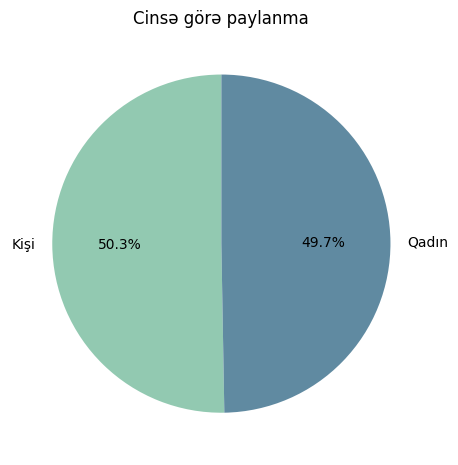

In [57]:
cins_counts = df['Cins'].value_counts()

plt.figure(figsize=(12,10))
plt.subplot(1,2,1)
plt.pie(
    cins_counts,
    labels=cins_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#92C9B1', '#608AA1']
)
plt.title('Cinsə görə paylanma')
plt.show()




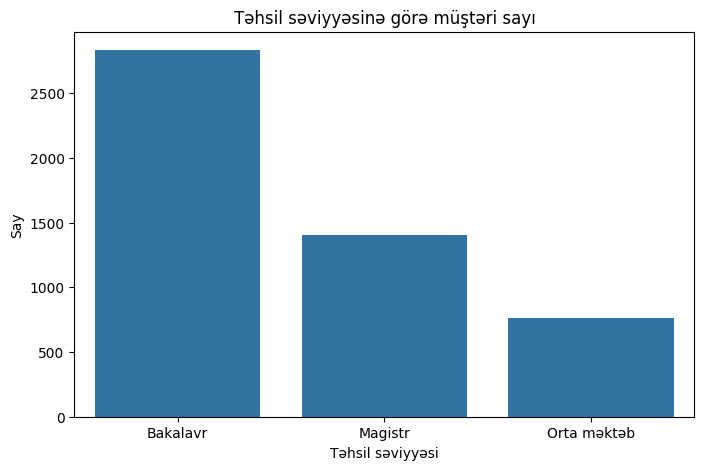

In [58]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='TəhsilSəviyyəsi', order=df['TəhsilSəviyyəsi'].value_counts().index)
plt.title("Təhsil səviyyəsinə görə müştəri sayı")
plt.xlabel("Təhsil səviyyəsi")
plt.ylabel("Say")
plt.show()

In [59]:
df['DoğumTarixi'] = pd.to_datetime(df['DoğumTarixi'], errors='coerce')
df['Yaş'] = (pd.Timestamp.now() - df['DoğumTarixi']).dt.days // 365
df = df[(df['Yaş'] > 0) & (df['Yaş'] < 100)]

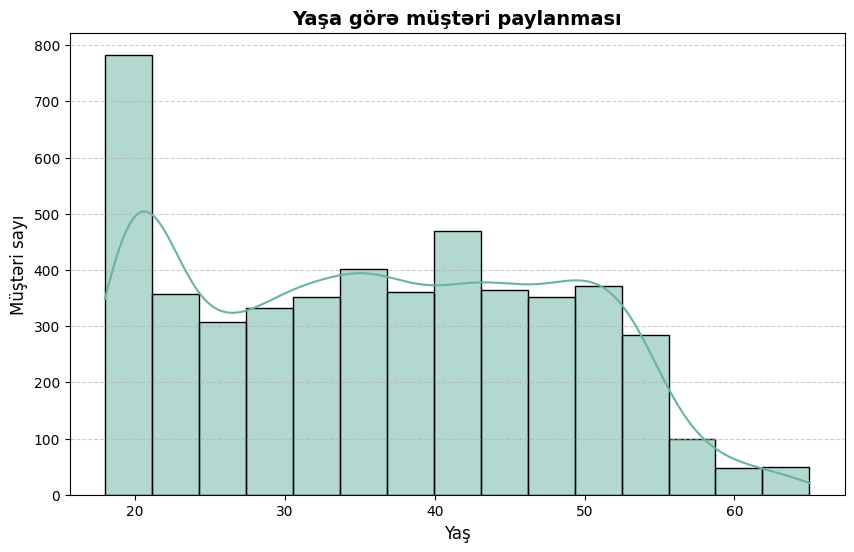

In [60]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Yaş'], bins=15, kde=True, color='#69b3a2', edgecolor='black')

plt.title('Yaşa görə müştəri paylanması', fontsize=14, fontweight='bold')
plt.xlabel('Yaş', fontsize=12)
plt.ylabel('Müştəri sayı', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


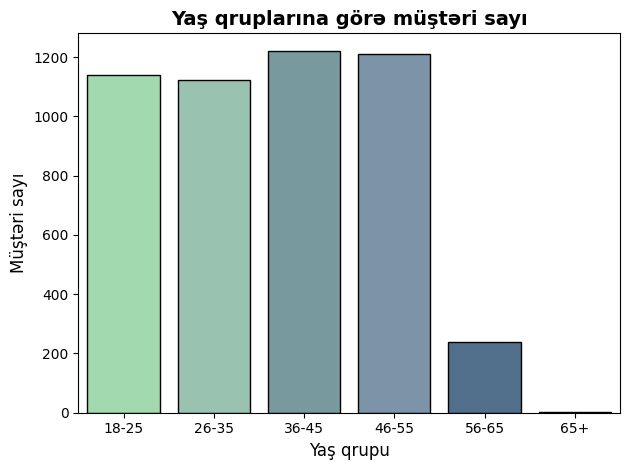

In [75]:
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Yaş_Qrupu'] = pd.cut(df['Yaş'], bins=bins, labels=labels, right=False)

colors = ['#9AE2AA', '#92C9B1', '#719FA6', '#7593af', '#476f95', '#194a7a']

sns.countplot(
    data=df,
    x='Yaş_Qrupu',
    hue='Yaş_Qrupu',
    palette=colors,
    legend=False,
    edgecolor='black'
)

plt.title('Yaş qruplarına görə müştəri sayı', fontsize=14, fontweight='bold')
plt.xlabel('Yaş qrupu', fontsize=12)
plt.ylabel('Müştəri sayı', fontsize=12)
plt.tight_layout()
plt.show()




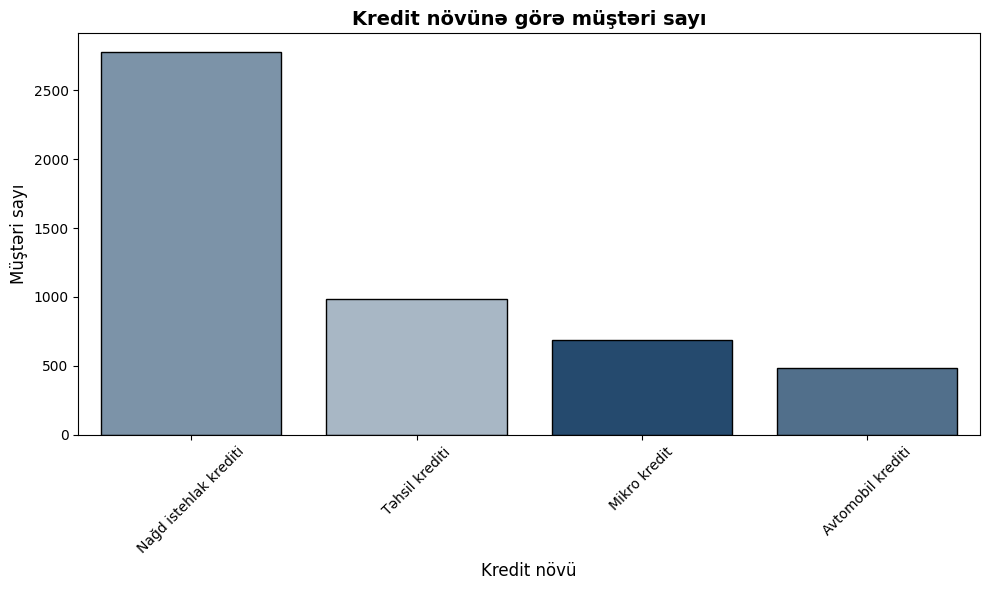

In [76]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x='KreditNövü',
    hue='KreditNövü',
    data=df,
    palette=['#a3b7ca', '#7593af', '#476f95', '#194a7a'],
    order=df['KreditNövü'].value_counts().index,
    legend=False,
    edgecolor='black'
)

plt.title('Kredit növünə görə müştəri sayı', fontsize=14, fontweight='bold')
plt.xlabel('Kredit növü', fontsize=12)
plt.ylabel('Müştəri sayı', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


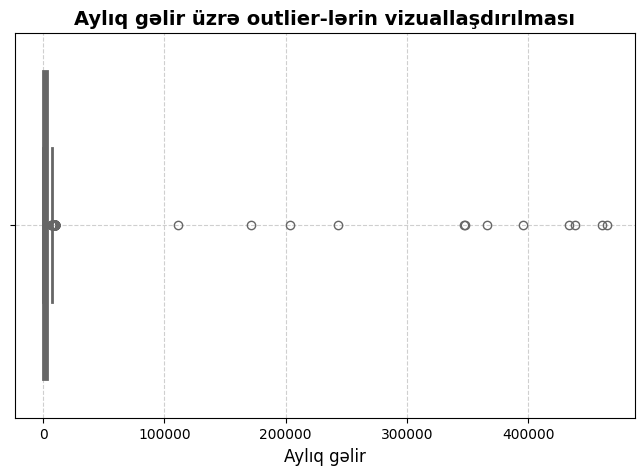

In [63]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['AylıqGəlir'], color='#91C4C3', fliersize=6, linewidth=2)
plt.title('Aylıq gəlir üzrə outlier-lərin vizuallaşdırılması', fontsize=14, fontweight='bold')
plt.xlabel('Aylıq gəlir', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [64]:
unique_high_incomes = sorted(df.loc[df['AylıqGəlir'] > 100000, 'AylıqGəlir'].unique())
print(unique_high_incomes)


[np.float64(111058.0), np.float64(171800.0), np.float64(203323.0), np.float64(242698.0), np.float64(347020.0), np.float64(347599.0), np.float64(365874.0), np.float64(395724.0), np.float64(433399.0), np.float64(438134.0), np.float64(460651.0), np.float64(464535.0)]


In [65]:
Q1 = df['AylıqGəlir'].quantile(0.25)
Q3 = df['AylıqGəlir'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df['AylıqGəlir'] = np.where(
    df['AylıqGəlir'] > upper_limit, upper_limit,
    np.where(df['AylıqGəlir'] < lower_limit, lower_limit, df['AylıqGəlir'])
)


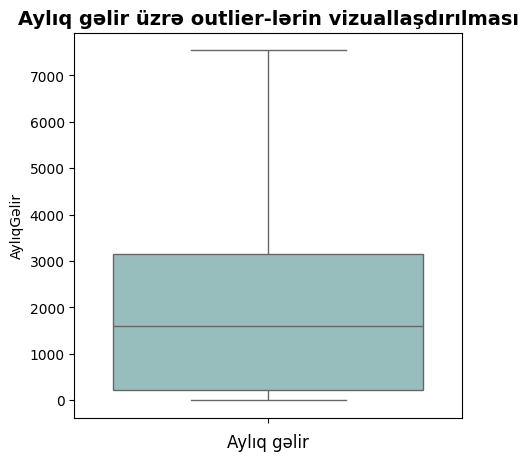

In [66]:
plt.figure(figsize=(5, 5))
sns.boxplot(df['AylıqGəlir'], color='#91C4C3')
plt.title('Aylıq gəlir üzrə outlier-lərin vizuallaşdırılması', fontsize=14, fontweight='bold')
plt.xlabel('Aylıq gəlir', fontsize=12)
plt.show()


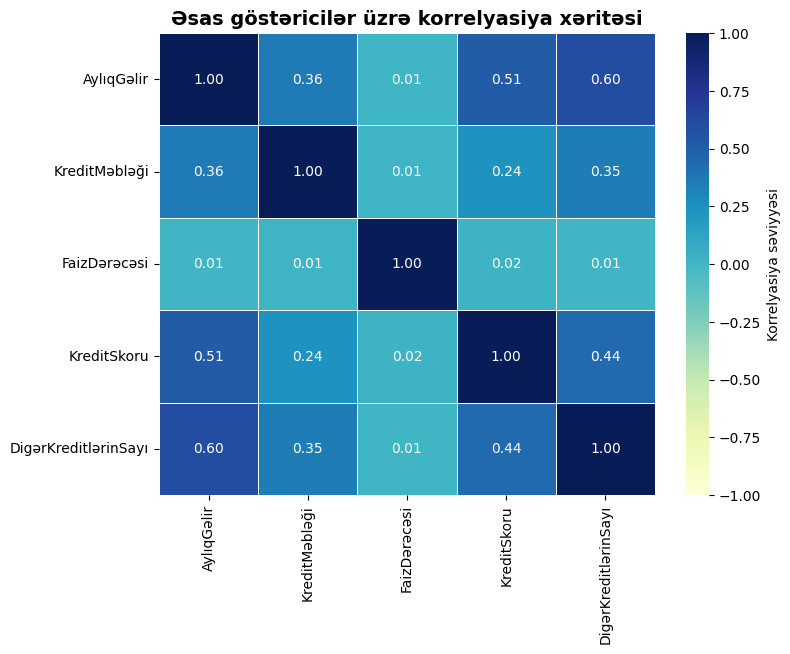

In [67]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['AylıqGəlir','KreditMəbləği','FaizDərəcəsi','KreditSkoru','DigərKreditlərinSayı']].corr(),
    annot=True,
    cmap=sns.color_palette("YlGnBu", as_cmap=True),
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={'label': 'Korrelyasiya səviyyəsi'},
    vmin=-1, vmax=1
)
plt.title("Əsas göstəricilər üzrə korrelyasiya xəritəsi", fontsize=14, fontweight='bold')
plt.show()


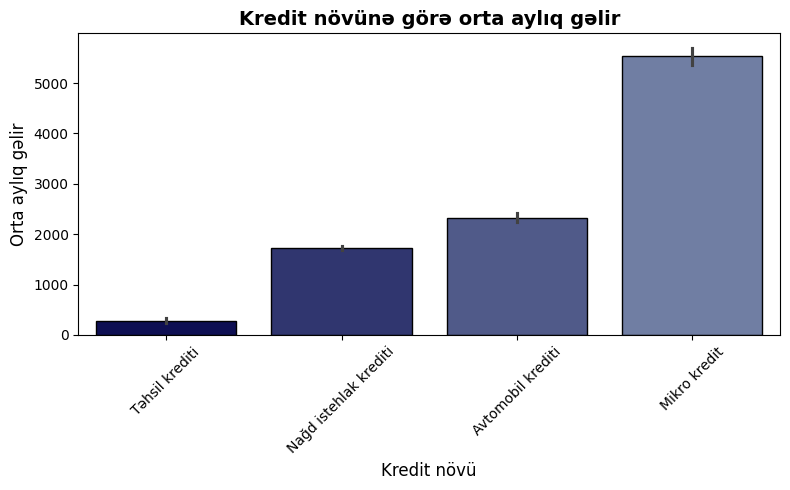

In [78]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='KreditNövü',
    y='AylıqGəlir',
    hue='KreditNövü',
    estimator='mean',
    palette=['#03045e', '#262d79', '#475492', '#677bab'],
    legend=False,
    edgecolor='black'
)

plt.title('Kredit növünə görə orta aylıq gəlir', fontsize=14, fontweight='bold')
plt.xlabel('Kredit növü', fontsize=12)
plt.ylabel('Orta aylıq gəlir', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



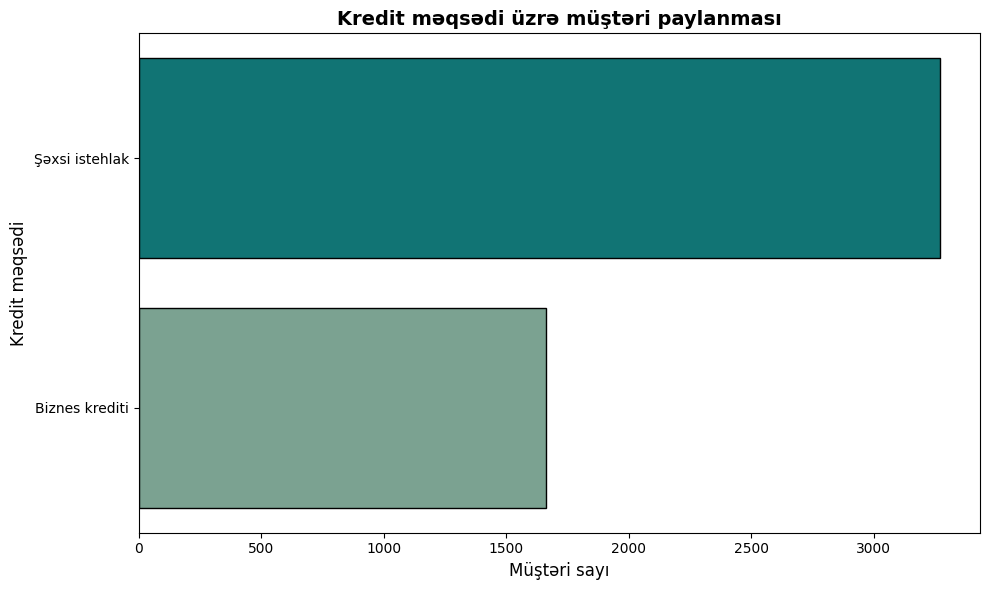

In [80]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y='KreditMəqsədi',
    hue='KreditMəqsədi',
    palette=['#74a892', '#008585'],
    order=df['KreditMəqsədi'].value_counts().index,
    legend=False,
    edgecolor='black'
)

plt.title('Kredit məqsədi üzrə müştəri paylanması', fontsize=14, fontweight='bold')
plt.xlabel('Müştəri sayı', fontsize=12)
plt.ylabel('Kredit məqsədi', fontsize=12)
plt.tight_layout()
plt.show()



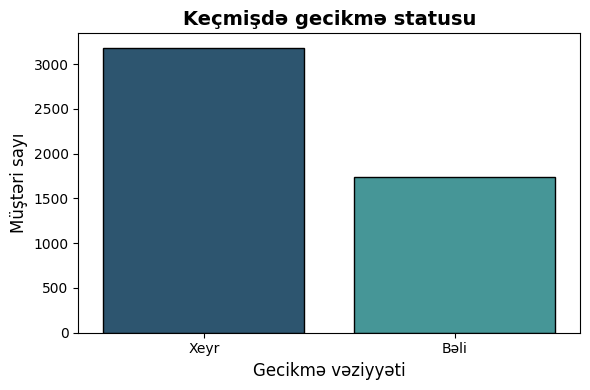

In [82]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='KeçmişdəGecikmə',
    hue='KeçmişdəGecikmə',
    palette=['#22577A', '#38A3A5'],
    legend=False,
    edgecolor='black'
)

plt.title('Keçmişdə gecikmə statusu', fontsize=14, fontweight='bold')
plt.xlabel('Gecikmə vəziyyəti', fontsize=12)
plt.ylabel('Müştəri sayı', fontsize=12)
plt.tight_layout()
plt.show()



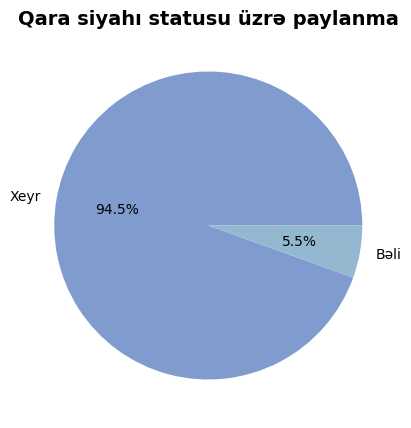

In [71]:
qara_siyahi = df['QaraSiyahida'].value_counts(normalize=True) * 100
plt.figure(figsize=(5,5))
plt.pie(qara_siyahi, labels=qara_siyahi.index, autopct='%1.1f%%', colors=['#809bce','#95b8d1'])
plt.title('Qara siyahı statusu üzrə paylanma', fontsize=14, fontweight='bold')
plt.show()
